In [1]:
# Import standard libraries
from pathlib import Path
import sys
import warnings

# Import scientific computing libraries
import geopandas as gpd
import matplotlib.pyplot as plt
import pandas as pd

# Add project root to path
sys.path.append("../")

# Import project-specific modules
from src.plots.continuous_maps import russia_continuous_multiplot
from src.utils.logger import setup_logger

# Configure logger
logger = setup_logger("forcings_final", log_file="../logs/forcings_final_analysis.log")

# Suppress warnings
warnings.filterwarnings("ignore")

# Configure matplotlib
plt.rcParams["font.family"] = "DeJavu Serif"
plt.rcParams["font.serif"] = ["Times New Roman"]

logger.info("Imports complete. Starting cross-entity analysis workflow.")
print("✓ Libraries loaded successfully")

2025-10-13 17:15:24 | INFO     | camels_ru | forcings_final | ℹ️  Imports complete. Starting cross-entity analysis workflow.


✓ Libraries loaded successfully


# Cross-Entity Analysis: Precipitation, Temperature, and Discharge Relationships

## Comprehensive Hydrometeorological Analysis for CAMELS-RU

This notebook provides a thorough cross-entity analysis examining the relationships between meteorological forcings (precipitation and temperature) and hydrological response (discharge) across Russian catchments.

### Analysis Objectives:
1. **Trend Analysis**: Identify temporal trends in precipitation, temperature, and discharge
2. **Correlation Analysis**: Quantify relationships between meteorological drivers and discharge
3. **Water Balance**: Calculate runoff coefficients and volume-based relationships  
4. **Spatial Coherence**: Examine geographical patterns in forcing-response relationships
5. **Cluster-Based Analysis**: Compare relationships across hydrological and geographical clusters

### Data Sources:
- **Discharge**: CAMELS-RU daily discharge (2008-2023), high-quality gauges only
- **Precipitation**: ERA5-Land and MSWEP daily precipitation
- **Temperature**: ERA5-Land daily temperature (min, max, mean)
- **Geographical Clusters**: 15 clusters based on HydroATLAS physiographic attributes
- **Hydrological Clusters**: 15 clusters based on discharge regime patterns

### Key Metrics:
- Trends: Mann-Kendall test, Sen's slope estimator
- Correlations: Pearson and Spearman coefficients with lag analysis
- Water balance: Runoff coefficients, annual totals, P-Q relationships
- Spatial patterns: Latitude/longitude gradients, cluster-wise statistics

## 1. Setup and Data Loading

Import necessary libraries and load pre-computed analysis results.

### 1.1 Load Pre-Computed Analysis Results

Load hydrological metrics, meteorological trends/correlations, and geographical clustering.

In [ ]:
# Load hydrological analysis results
hydro_df = pd.read_csv(
    "../results/hydrological_analysis_complete.csv",
    index_col=0,
    dtype={"gauge_id": str},
)
hydro_df.index = hydro_df.index.astype(str)

# Load meteorological trends and correlations
meteo_trends_df = pd.read_csv(
    "../results/meteo_discharge_trends_correlations.csv",
    index_col="gauge_id",
    dtype={"gauge_id": str},
)

# Load geographical cluster information
geo_clusters_df = pd.read_csv(
    "../results/geo_gauge_cluster_analysis_15_detailed.csv",
    index_col="gauge_id",
    dtype={"gauge_id": str},
)
geo_clusters_df = geo_clusters_df.rename(
    columns={"cluster_id": "geo_cluster_id", "cluster_name": "geo_cluster_name"},
)

# Load spatial data
gauge_gdf = gpd.read_file("../data/Geometry/GaugeGeomCAMELS.gpkg")
gauge_gdf.set_index("gauge_id", inplace=True)
gauge_gdf.index = gauge_gdf.index.astype(str)

ws_gdf = gpd.read_file("../data/Geometry/WatershedGeomCAMELS.gpkg")
ws_gdf.set_index("gauge_id", inplace=True)
ws_gdf.index = ws_gdf.index.astype(str)

basemap_data = gpd.read_file("../data/Geometry/basemap.gpkg")

print(f"✓ Loaded hydrological analysis: {len(hydro_df)} gauges")
print(f"✓ Loaded meteo trends/correlations: {len(meteo_trends_df)} gauges")
print(f"✓ Loaded geographical clusters: {len(geo_clusters_df)} gauges")
print(f"✓ Loaded gauge geometries: {len(gauge_gdf)} points")
print(f"✓ Loaded watershed geometries: {len(ws_gdf)} polygons")

logger.info("All datasets loaded successfully")

2025-10-13 17:15:26 | INFO     | camels_ru | forcings_final | ℹ️  All datasets loaded successfully


✓ Loaded hydrological analysis: 1463 gauges
✓ Loaded meteo trends/correlations: 1579 gauges
✓ Loaded geographical clusters: 2251 gauges
✓ Loaded gauge geometries: 2638 points
✓ Loaded watershed geometries: 2638 polygons


### 1.2 Merge All Datasets

Combine hydrological, meteorological, and geographical information into a comprehensive dataset.

In [20]:
# Merge all datasets
combined_df = gauge_gdf.join(hydro_df, how="inner", rsuffix="_hydro")
combined_df = combined_df.join(meteo_trends_df, how="inner", rsuffix="_meteo")
combined_df = combined_df.join(
    geo_clusters_df[[col for col in geo_clusters_df.columns if not col.startswith("geo_cluster")]],
    how="left",
)
combined_df = combined_df.join(ws_gdf[["area"]], how="left", rsuffix="_ws")

# Add latitude and longitude as explicit columns
combined_df["latitude"] = combined_df.geometry.y
combined_df["longitude"] = combined_df.geometry.x

print(f"✓ Combined dataset: {len(combined_df)} gauges")
print(f"✓ Total columns: {len(combined_df.columns)}")
print("\nKey metrics available:")
print(
    f"  - Discharge metrics: {len([c for c in combined_df.columns if c.startswith('mean_') or c.startswith('q')])} columns"
)
print(f"  - Precipitation trends: {len([c for c in combined_df.columns if 'prcp' in c])} columns")
print(f"  - Temperature metrics: {len([c for c in combined_df.columns if 'temp' in c])} columns")
print(
    f"  - Correlations: {len([c for c in combined_df.columns if 'pearson' in c or 'spearman' in c])} columns"
)

# Display sample data
print("\nSample gauge data (first row):")
print(
    combined_df.iloc[0][
        [
            "geo_cluster_name",
            "hydro_cluster_id",
            "mean_discharge",
            "prcp_era5_sen_slope",
            "temp_sen_slope",
            "q_sen_slope",
        ]
    ].to_dict()
)

logger.info(f"Merged all datasets: {len(combined_df)} gauges with {len(combined_df.columns)} attributes")

2025-10-13 17:19:10 | INFO     | camels_ru | forcings_final | ℹ️  Merged all datasets: 1463 gauges with 159 attributes


✓ Combined dataset: 1463 gauges
✓ Total columns: 159

Key metrics available:
  - Discharge metrics: 14 columns
  - Precipitation trends: 26 columns
  - Temperature metrics: 19 columns
  - Correlations: 16 columns

Sample gauge data (first row):
{'geo_cluster_name': 'Cropland (64.0%) / Clay-rich', 'hydro_cluster_id': 5, 'mean_discharge': 0.0826836950283854, 'prcp_era5_sen_slope': 4.308455131417966, 'temp_sen_slope': 0.0348904191557117, 'q_sen_slope': -0.0020423272319835}


## 2. Temporal Trend Analysis

### 2.1 Summary of Trends in Precipitation, Temperature, and Discharge

Analyze the prevalence and direction of significant trends across all variables.

In [21]:
# Trend summary function
def summarize_trends(df, variable_prefix, variable_name):
    """Summarize trends for a given variable."""
    mk_trend_col = f"{variable_prefix}_mk_trend"
    mk_pval_col = f"{variable_prefix}_mk_p_value"
    sen_slope_col = f"{variable_prefix}_sen_slope"

    if mk_trend_col not in df.columns:
        return None

    total = df[mk_trend_col].notna().sum()
    significant = (df[mk_pval_col] < 0.05).sum()
    increasing = ((df[mk_pval_col] < 0.05) & (df[mk_trend_col] > 0)).sum()
    decreasing = ((df[mk_pval_col] < 0.05) & (df[mk_trend_col] < 0)).sum()
    mean_slope = df[sen_slope_col].mean()
    median_slope = df[sen_slope_col].median()

    return {
        "Variable": variable_name,
        "Total Gauges": total,
        "Significant Trends": significant,
        "% Significant": f"{100 * significant / total:.1f}%" if total > 0 else "N/A",
        "Increasing": increasing,
        "% Increasing": f"{100 * increasing / total:.1f}%" if total > 0 else "N/A",
        "Decreasing": decreasing,
        "% Decreasing": f"{100 * decreasing / total:.1f}%" if total > 0 else "N/A",
        "Mean Sen's Slope": f"{mean_slope:.4f}",
        "Median Sen's Slope": f"{median_slope:.4f}",
    }


# Calculate trend summaries
trend_variables = [
    ("prcp_era5", "Precipitation (ERA5-Land)"),
    ("prcp_mswep", "Precipitation (MSWEP)"),
    ("temp", "Temperature"),
    ("gdd", "Growing Degree Days"),
    ("frost", "Frost Days"),
    ("q", "Discharge"),
]

trend_summary_list = []
for prefix, name in trend_variables:
    summary = summarize_trends(combined_df, prefix, name)
    if summary:
        trend_summary_list.append(summary)

trend_summary_table = pd.DataFrame(trend_summary_list)

print("=" * 100)
print("TREND ANALYSIS SUMMARY (Mann-Kendall Test, 2008-2023)")
print("=" * 100)
print(trend_summary_table.to_string(index=False))
print("=" * 100)

# Save to CSV
trend_summary_table.to_csv("../results/trend_summary_all_variables.csv", index=False)
logger.info("Trend summary table created and saved")
print("\n✓ Trend summary saved to: ../results/trend_summary_all_variables.csv")

2025-10-13 17:19:17 | INFO     | camels_ru | forcings_final | ℹ️  Trend summary table created and saved


TREND ANALYSIS SUMMARY (Mann-Kendall Test, 2008-2023)
                 Variable  Total Gauges  Significant Trends % Significant  Increasing % Increasing  Decreasing % Decreasing Mean Sen's Slope Median Sen's Slope
Precipitation (ERA5-Land)          1463                 130          8.9%           1         0.1%         129         8.8%         -13.6085           -12.2461
    Precipitation (MSWEP)          1463                  30          2.1%          25         1.7%           5         0.3%           1.4143             0.5501
              Temperature          1463                   3          0.2%           0         0.0%           3         0.2%          -0.0056            -0.0068
      Growing Degree Days          1463                  42          2.9%          22         1.5%          20         1.4%           0.2457             2.1701
               Frost Days          1463                  47          3.2%           0         0.0%          47         3.2%          -0.3533      

### 2.2 Spatial Distribution of Trends

Examine geographical patterns in meteorological and hydrological trends.

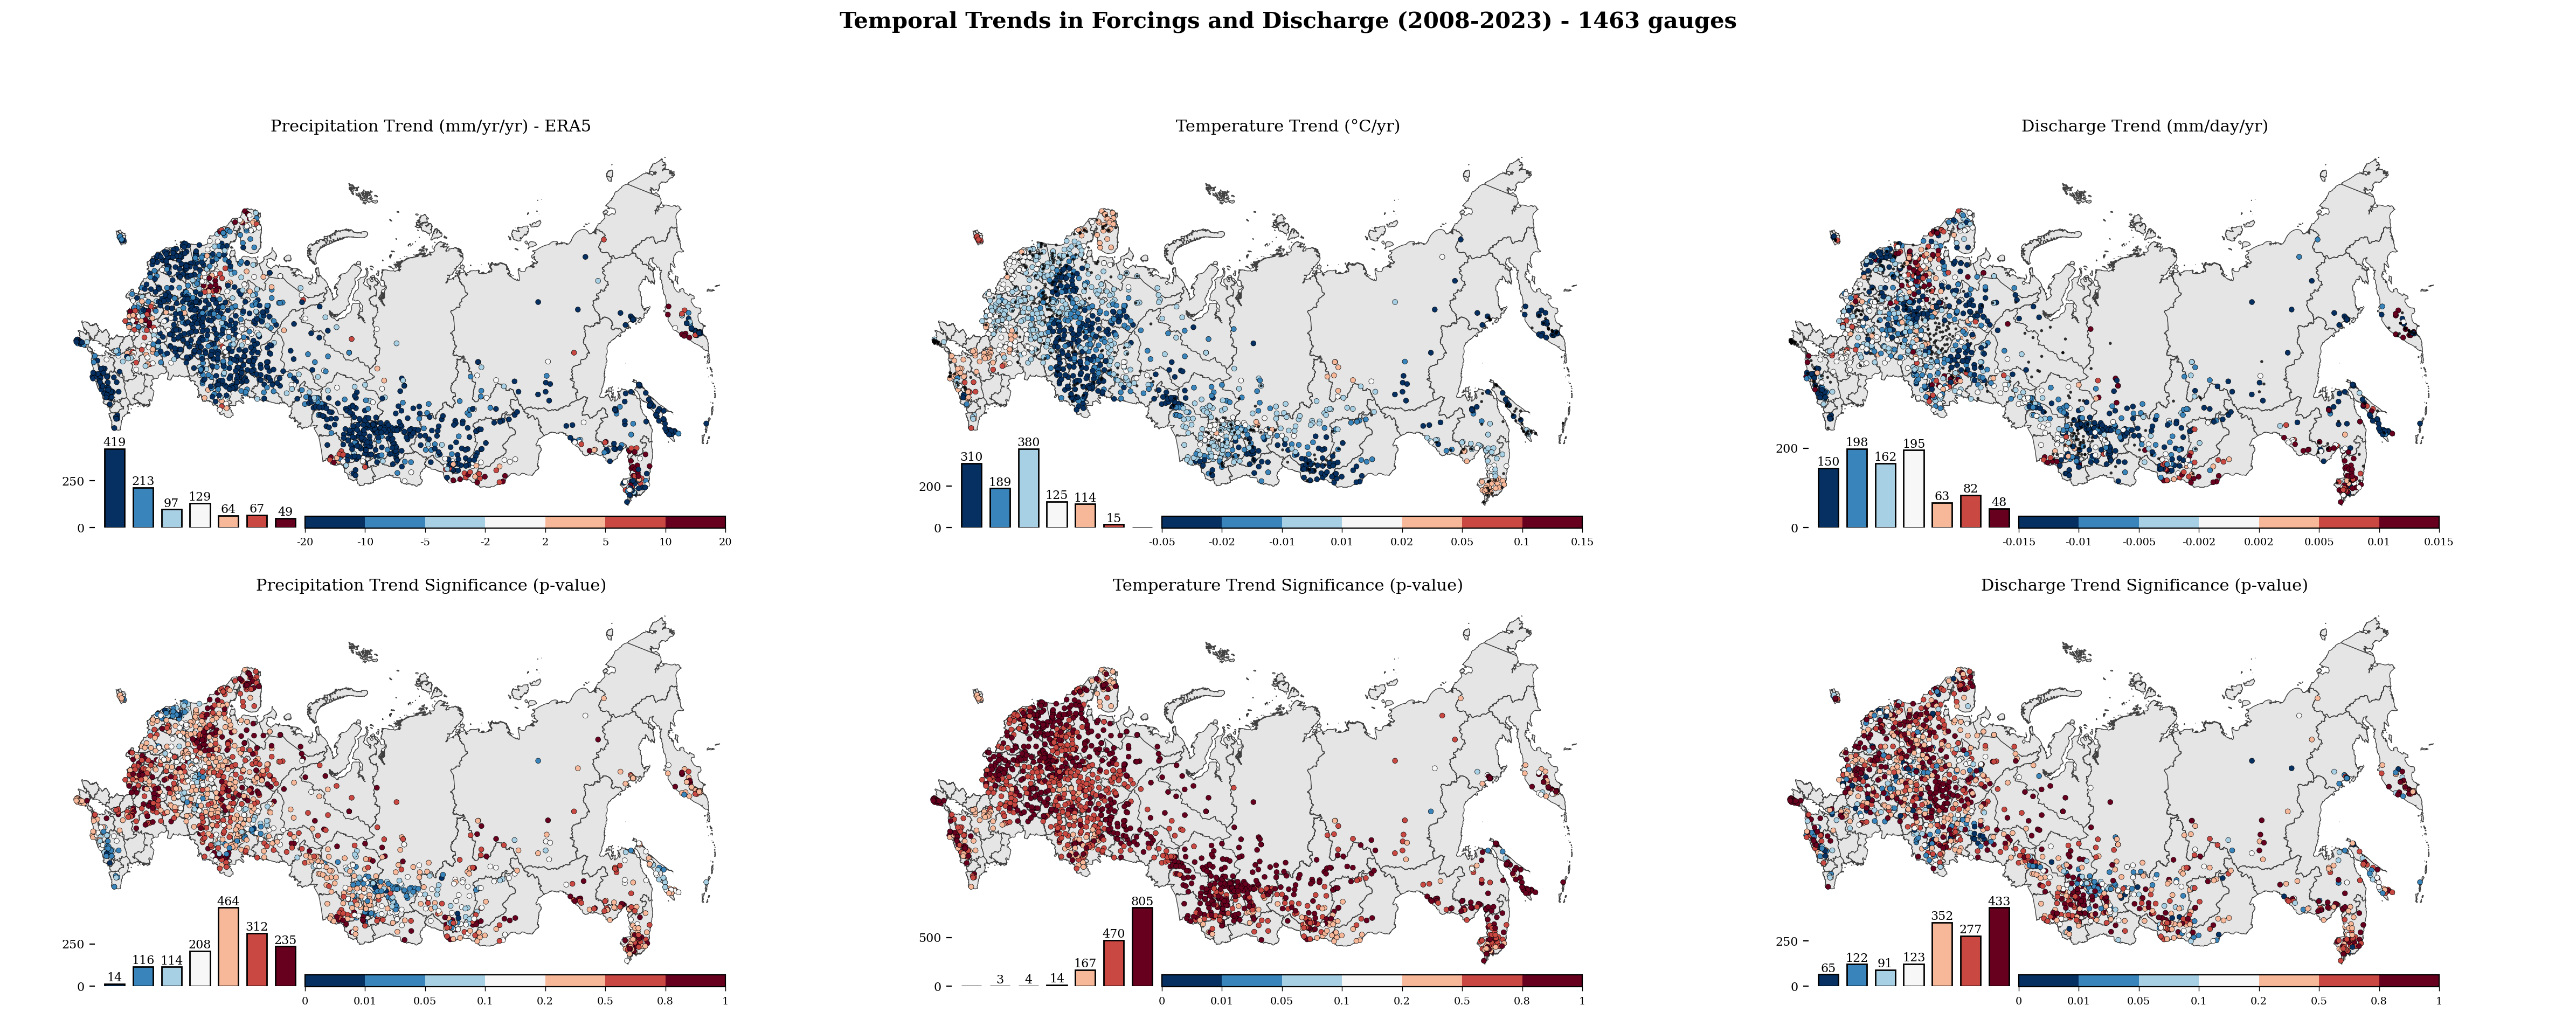

2025-10-13 17:19:22 | INFO     | camels_ru | forcings_final | ℹ️  Trend spatial maps created


✓ Trend maps saved


In [22]:
# Select trend metrics for spatial visualization
trend_metrics = [
    "prcp_era5_sen_slope",
    "temp_sen_slope",
    "q_sen_slope",
    "prcp_era5_mk_p_value",
    "temp_mk_p_value",
    "q_mk_p_value",
]

trend_titles = [
    "Precipitation Trend (mm/yr/yr) - ERA5",
    "Temperature Trend (°C/yr)",
    "Discharge Trend (mm/day/yr)",
    "Precipitation Trend Significance (p-value)",
    "Temperature Trend Significance (p-value)",
    "Discharge Trend Significance (p-value)",
]

# Define bin intervals for trends
trend_bin_intervals = {
    "prcp_era5_sen_slope": [(-20, -10), (-10, -5), (-5, -2), (-2, 2), (2, 5), (5, 10), (10, 20)],
    "temp_sen_slope": [
        (-0.05, -0.02),
        (-0.02, -0.01),
        (-0.01, 0.01),
        (0.01, 0.02),
        (0.02, 0.05),
        (0.05, 0.10),
        (0.10, 0.15),
    ],
    "q_sen_slope": [
        (-0.015, -0.010),
        (-0.010, -0.005),
        (-0.005, -0.002),
        (-0.002, 0.002),
        (0.002, 0.005),
        (0.005, 0.010),
        (0.010, 0.015),
    ],
    "prcp_era5_mk_p_value": [
        (0.0, 0.01),
        (0.01, 0.05),
        (0.05, 0.10),
        (0.10, 0.20),
        (0.20, 0.50),
        (0.50, 0.80),
        (0.80, 1.0),
    ],
    "temp_mk_p_value": [
        (0.0, 0.01),
        (0.01, 0.05),
        (0.05, 0.10),
        (0.10, 0.20),
        (0.20, 0.50),
        (0.50, 0.80),
        (0.80, 1.0),
    ],
    "q_mk_p_value": [
        (0.0, 0.01),
        (0.01, 0.05),
        (0.05, 0.10),
        (0.10, 0.20),
        (0.20, 0.50),
        (0.50, 0.80),
        (0.80, 1.0),
    ],
}

# Create spatial maps
fig_trends = russia_continuous_multiplot(
    gdf_to_plot=combined_df,
    basemap_data=basemap_data,
    metrics=trend_metrics,
    titles=trend_titles,
    main_title=f"Temporal Trends in Forcings and Discharge (2008-2023) - {len(combined_df)} gauges",
    bin_intervals=trend_bin_intervals,
    cmap_name="RdBu_r",
    ncols=3,
    subplot_size=(8.0, 5.0),
    with_histogram=True,
    marker_size=12,
)

fig_trends.savefig("../paper/images/forcings_trends_spatial_maps.png", dpi=300, bbox_inches="tight")
display(fig_trends)

logger.info("Trend spatial maps created")
print("✓ Trend maps saved")

## 3. Correlation Analysis: Forcings vs Discharge

### 3.1 Summary of Precipitation-Discharge Relationships

Examine the strength and spatial patterns of P-Q correlations.

In [23]:
# Correlation summary statistics
corr_metrics = [
    ("prcp_era5_q_pearson_r", "Precipitation (ERA5) - Discharge"),
    ("prcp_mswep_q_pearson_r", "Precipitation (MSWEP) - Discharge"),
    ("temp_q_pearson_r", "Temperature - Discharge"),
    ("spring_temp_q_pearson_r", "Spring Temperature - Discharge"),
]

corr_summary_list = []
for corr_col, corr_name in corr_metrics:
    if corr_col in combined_df.columns:
        data = combined_df[corr_col].dropna()
        strong_pos = (data > 0.5).sum()
        moderate_pos = ((data > 0.3) & (data <= 0.5)).sum()
        weak_corr = ((data > -0.3) & (data <= 0.3)).sum()
        moderate_neg = ((data >= -0.5) & (data < -0.3)).sum()
        strong_neg = (data < -0.5).sum()

        corr_summary_list.append(
            {
                "Relationship": corr_name,
                "N Gauges": len(data),
                "Mean r": f"{data.mean():.3f}",
                "Median r": f"{data.median():.3f}",
                "Strong Positive (r>0.5)": f"{strong_pos} ({100 * strong_pos / len(data):.1f}%)",
                "Moderate Positive (0.3-0.5)": f"{moderate_pos} ({100 * moderate_pos / len(data):.1f}%)",
                "Weak (-0.3 to 0.3)": f"{weak_corr} ({100 * weak_corr / len(data):.1f}%)",
                "Moderate Negative (-0.5 to -0.3)": f"{moderate_neg} ({100 * moderate_neg / len(data):.1f}%)",
                "Strong Negative (r<-0.5)": f"{strong_neg} ({100 * strong_neg / len(data):.1f}%)",
            }
        )

corr_summary_table = pd.DataFrame(corr_summary_list)

print("=" * 120)
print("CORRELATION ANALYSIS SUMMARY (Pearson Correlation)")
print("=" * 120)
print(corr_summary_table.to_string(index=False))
print("=" * 120)

# Save to CSV
corr_summary_table.to_csv("../results/correlation_summary_forcings_discharge.csv", index=False)
logger.info("Correlation summary table created")
print("\n✓ Correlation summary saved")

2025-10-13 17:19:40 | INFO     | camels_ru | forcings_final | ℹ️  Correlation summary table created


CORRELATION ANALYSIS SUMMARY (Pearson Correlation)
                     Relationship  N Gauges Mean r Median r Strong Positive (r>0.5) Moderate Positive (0.3-0.5) Weak (-0.3 to 0.3) Moderate Negative (-0.5 to -0.3) Strong Negative (r<-0.5)
 Precipitation (ERA5) - Discharge       932  0.078    0.042                0 (0.0%)                   45 (4.8%)        887 (95.2%)                         0 (0.0%)                 0 (0.0%)
Precipitation (MSWEP) - Discharge       932  0.057    0.026                0 (0.0%)                   10 (1.1%)        922 (98.9%)                         0 (0.0%)                 0 (0.0%)
          Temperature - Discharge       744  0.216    0.195             122 (16.4%)                 118 (15.9%)        499 (67.1%)                         5 (0.7%)                 0 (0.0%)
   Spring Temperature - Discharge       812  0.327    0.382             257 (31.7%)                 217 (26.7%)        331 (40.8%)                         7 (0.9%)                 0 (0.0%)

✓ C

## 4. Water Balance and Volume Relationships

### 4.1 Calculate Runoff Coefficients and Volume Metrics

Use the new water_balance module to calculate comprehensive water balance metrics.

In [24]:
# Import water balance module
from src.meteo.water_balance import calculate_water_balance_metrics

# Load time series data for water balance calculation
era5_dir = Path("../data/MeteoData/CamelsRU/era5_land")
mswep_dir = Path("../data/MeteoData/CamelsRU/mswep")
discharge_dir_partial = Path("../data/HydroFiles/Discharge/partial/decent")
discharge_dir_full = Path("../data/HydroFiles/Discharge/full/decent")

# Calculate water balance metrics for all gauges
water_balance_results = {}

for gauge_id in combined_df.index:
    try:
        # Load ERA5-Land data
        era5_path = era5_dir / f"{gauge_id}.csv"
        if era5_path.exists():
            era5_df = pd.read_csv(era5_path, index_col="date", parse_dates=True)
            prcp_era5 = era5_df["prcp"] if "prcp" in era5_df.columns else None
        else:
            prcp_era5 = None

        # Load MSWEP data
        mswep_path = mswep_dir / f"{gauge_id}.csv"
        if mswep_path.exists():
            mswep_df = pd.read_csv(mswep_path, index_col="date", parse_dates=True)
            prcp_mswep = (
                mswep_df["precipitation"].rename("prcp") if "precipitation" in mswep_df.columns else None
            )
        else:
            prcp_mswep = None

        # Load discharge data
        discharge_path_partial = discharge_dir_partial / f"{gauge_id}.csv"
        discharge_path_full = discharge_dir_full / f"{gauge_id}.csv"

        if discharge_path_partial.exists():
            discharge_df = pd.read_csv(discharge_path_partial, index_col="date", parse_dates=True)
        elif discharge_path_full.exists():
            discharge_df = pd.read_csv(discharge_path_full, index_col="date", parse_dates=True)
        else:
            continue

        discharge = discharge_df["q_mm_day"] if "q_mm_day" in discharge_df.columns else None

        if discharge is None:
            continue

        # Calculate water balance metrics
        wb_metrics = calculate_water_balance_metrics(
            precipitation_era5=prcp_era5,
            precipitation_mswep=prcp_mswep,
            discharge=discharge,
            period_type="hydrological",
            hydro_year_start_month=10,
        )

        water_balance_results[gauge_id] = wb_metrics

    except Exception as e:
        logger.error(f"Error calculating water balance for {gauge_id}: {e}")
        continue

# Convert to DataFrame
wb_df = pd.DataFrame.from_dict(water_balance_results, orient="index")

print(f"✓ Calculated water balance metrics for {len(wb_df)} gauges")
print(f"✓ Metrics calculated: {wb_df.columns.tolist()}")

# Merge with combined dataset
combined_df = combined_df.join(wb_df, how="left")

print(f"\n✓ Updated combined dataset: {len(combined_df)} gauges, {len(combined_df.columns)} columns")
logger.info(f"Water balance metrics calculated for {len(wb_df)} gauges")

2025-10-13 17:20:12 | INFO     | camels_ru | forcings_final | ℹ️  Water balance metrics calculated for 1463 gauges


✓ Calculated water balance metrics for 1463 gauges
✓ Metrics calculated: ['era5_mean_runoff_coefficient', 'era5_std_runoff_coefficient', 'era5_cv_runoff_coefficient', 'era5_mean_annual_prcp', 'era5_mean_annual_discharge', 'era5_mean_water_deficit', 'era5_prcp_discharge_correlation', 'era5_prcp_discharge_slope', 'era5_prcp_discharge_intercept', 'era5_prcp_discharge_r_squared', 'mswep_mean_runoff_coefficient', 'mswep_std_runoff_coefficient', 'mswep_cv_runoff_coefficient', 'mswep_mean_annual_prcp', 'mswep_mean_annual_discharge', 'mswep_mean_water_deficit', 'mswep_prcp_discharge_correlation', 'mswep_prcp_discharge_slope', 'mswep_prcp_discharge_intercept', 'mswep_prcp_discharge_r_squared']

✓ Updated combined dataset: 1463 gauges, 179 columns


## 5. Cluster-Based Comparative Analysis

### 5.1 Compare Trends and Correlations by Geographical Cluster

Analyze how forcing-discharge relationships vary across physiographic regions.

In [25]:
# Cluster-based analysis by geographical cluster
geo_cluster_analysis = combined_df.groupby("geo_cluster_name").agg(
    {
        # Precipitation trends
        "prcp_era5_sen_slope": ["mean", "median", "std"],
        "prcp_era5_mk_p_value": lambda x: (x < 0.05).sum(),  # Count significant
        # Temperature trends
        "temp_sen_slope": ["mean", "median", "std"],
        "temp_mk_p_value": lambda x: (x < 0.05).sum(),
        # Discharge trends
        "q_sen_slope": ["mean", "median", "std"],
        "q_mk_p_value": lambda x: (x < 0.05).sum(),
        # Correlations
        "prcp_era5_q_pearson_r": ["mean", "median", "std"],
        "temp_q_pearson_r": ["mean", "median", "std"],
        # Water balance
        "era5_mean_runoff_coefficient": ["mean", "median", "std"],
        "era5_mean_annual_prcp": ["mean", "median"],
        "era5_mean_annual_discharge": ["mean", "median"],
        "era5_mean_water_deficit": ["mean", "median"],
    }
)

# Flatten column names
geo_cluster_analysis.columns = ["_".join(col).strip() for col in geo_cluster_analysis.columns]

# Sort by cluster name
geo_cluster_analysis = geo_cluster_analysis.sort_index()

print("=" * 120)
print("GEOGRAPHICAL CLUSTER ANALYSIS: Trends, Correlations, and Water Balance")
print("=" * 120)
print(geo_cluster_analysis.head(10).to_string())
print("=" * 120)

# Save to CSV
geo_cluster_analysis.to_csv("../results/geo_cluster_forcings_analysis.csv")
logger.info("Geographical cluster analysis saved")
print("\n✓ Cluster analysis saved to: ../results/geo_cluster_forcings_analysis.csv")

2025-10-13 17:20:12 | INFO     | camels_ru | forcings_final | ℹ️  Geographical cluster analysis saved


GEOGRAPHICAL CLUSTER ANALYSIS: Trends, Correlations, and Water Balance
                                      prcp_era5_sen_slope_mean  prcp_era5_sen_slope_median  prcp_era5_sen_slope_std  prcp_era5_mk_p_value_<lambda>  temp_sen_slope_mean  temp_sen_slope_median  temp_sen_slope_std  temp_mk_p_value_<lambda>  q_sen_slope_mean  q_sen_slope_median  q_sen_slope_std  q_mk_p_value_<lambda>  prcp_era5_q_pearson_r_mean  prcp_era5_q_pearson_r_median  prcp_era5_q_pearson_r_std  temp_q_pearson_r_mean  temp_q_pearson_r_median  temp_q_pearson_r_std  era5_mean_runoff_coefficient_mean  era5_mean_runoff_coefficient_median  era5_mean_runoff_coefficient_std  era5_mean_annual_prcp_mean  era5_mean_annual_prcp_median  era5_mean_annual_discharge_mean  era5_mean_annual_discharge_median  era5_mean_water_deficit_mean  era5_mean_water_deficit_median
geo_cluster_name                                                                                                                                                     

### 5.2 Compare by Hydrological Cluster

Analyze how forcing-discharge relationships vary across different discharge regime types.

In [26]:
# Cluster-based analysis by hydrological cluster
if "Hydro cluster" in combined_df.columns:
    hydro_cluster_analysis = combined_df.groupby("Hydro cluster").agg(
        {
            # Correlations (key for regime types)
            "prcp_era5_q_pearson_r": ["mean", "median", "std", "count"],
            "temp_q_pearson_r": ["mean", "median", "std"],
            "spring_temp_q_pearson_r": ["mean", "median", "std"],
            # Lag effects
            "prcp_era5_q_best_lag": ["mean", "median"],
            "temp_q_best_lag": ["mean", "median"],
            # Water balance
            "era5_mean_runoff_coefficient": ["mean", "median", "std"],
            "era5_mean_water_deficit": ["mean", "median"],
            # Trends
            "q_sen_slope": ["mean", "median"],
            "prcp_era5_sen_slope": ["mean", "median"],
            "temp_sen_slope": ["mean", "median"],
        }
    )

    # Flatten column names
    hydro_cluster_analysis.columns = ["_".join(col).strip() for col in hydro_cluster_analysis.columns]

    print("=" * 120)
    print("HYDROLOGICAL CLUSTER ANALYSIS: Forcing-Response Relationships by Regime Type")
    print("=" * 120)
    print(hydro_cluster_analysis.to_string())
    print("=" * 120)

    # Save to CSV
    hydro_cluster_analysis.to_csv("../results/hydro_cluster_forcings_analysis.csv")
    logger.info("Hydrological cluster analysis saved")
    print("\n✓ Hydro cluster analysis saved")
else:
    print("⚠ Hydrological cluster information not available in dataset")

2025-10-13 17:20:54 | INFO     | camels_ru | forcings_final | ℹ️  Hydrological cluster analysis saved


HYDROLOGICAL CLUSTER ANALYSIS: Forcing-Response Relationships by Regime Type
               prcp_era5_q_pearson_r_mean  prcp_era5_q_pearson_r_median  prcp_era5_q_pearson_r_std  prcp_era5_q_pearson_r_count  temp_q_pearson_r_mean  temp_q_pearson_r_median  temp_q_pearson_r_std  spring_temp_q_pearson_r_mean  spring_temp_q_pearson_r_median  spring_temp_q_pearson_r_std  prcp_era5_q_best_lag_mean  prcp_era5_q_best_lag_median  temp_q_best_lag_mean  temp_q_best_lag_median  era5_mean_runoff_coefficient_mean  era5_mean_runoff_coefficient_median  era5_mean_runoff_coefficient_std  era5_mean_water_deficit_mean  era5_mean_water_deficit_median  q_sen_slope_mean  q_sen_slope_median  prcp_era5_sen_slope_mean  prcp_era5_sen_slope_median  temp_sen_slope_mean  temp_sen_slope_median
Hydro cluster                                                                                                                                                                                                                       

In [33]:
exmp = pd.read_csv(
    "../data/HydroFiles/Discharge/full/decent/10006.csv", parse_dates=["date"], index_col="date"
)

exmp["q_mm_day"].groupby(pd.Grouper(freq="YE")).sum()

date
2008-12-31    201.102012
2009-12-31    292.896797
2010-12-31    336.408259
2011-12-31    226.436639
2012-12-31    191.710307
2013-12-31    348.396227
2014-12-31    289.881862
2015-12-31    279.635867
2016-12-31    308.240120
2017-12-31    279.260557
2018-12-31    287.837348
2019-12-31    236.627808
2020-12-31    272.795068
2021-12-31    262.422973
2022-12-31    203.035877
2023-12-31    272.011056
Freq: YE-DEC, Name: q_mm_day, dtype: float64

In [38]:
exmp_meteo = pd.read_csv(
    "../data/MeteoData/CamelsRU/gpcp/10006.csv", parse_dates=["date"], index_col="date"
)

exmp_meteo["precip"].groupby(pd.Grouper(freq="YE")).sum()

date
2008-12-31    334.226380
2009-12-31    443.680359
2010-12-31    387.203398
2011-12-31    276.830350
2012-12-31    350.442485
2013-12-31    435.160215
2014-12-31    411.171543
2015-12-31    421.280740
2016-12-31    447.977426
2017-12-31    356.924147
2018-12-31    385.618079
2019-12-31    381.867305
2020-12-31    376.892290
2021-12-31    324.126968
2022-12-31    103.461478
2023-12-31    152.353553
Freq: YE-DEC, Name: precip, dtype: float64

## 6. Comprehensive Spatial Visualizations

### 6.1 Multi-Panel Correlation Maps

Visualize the spatial distribution of forcing-discharge correlations across Russia.

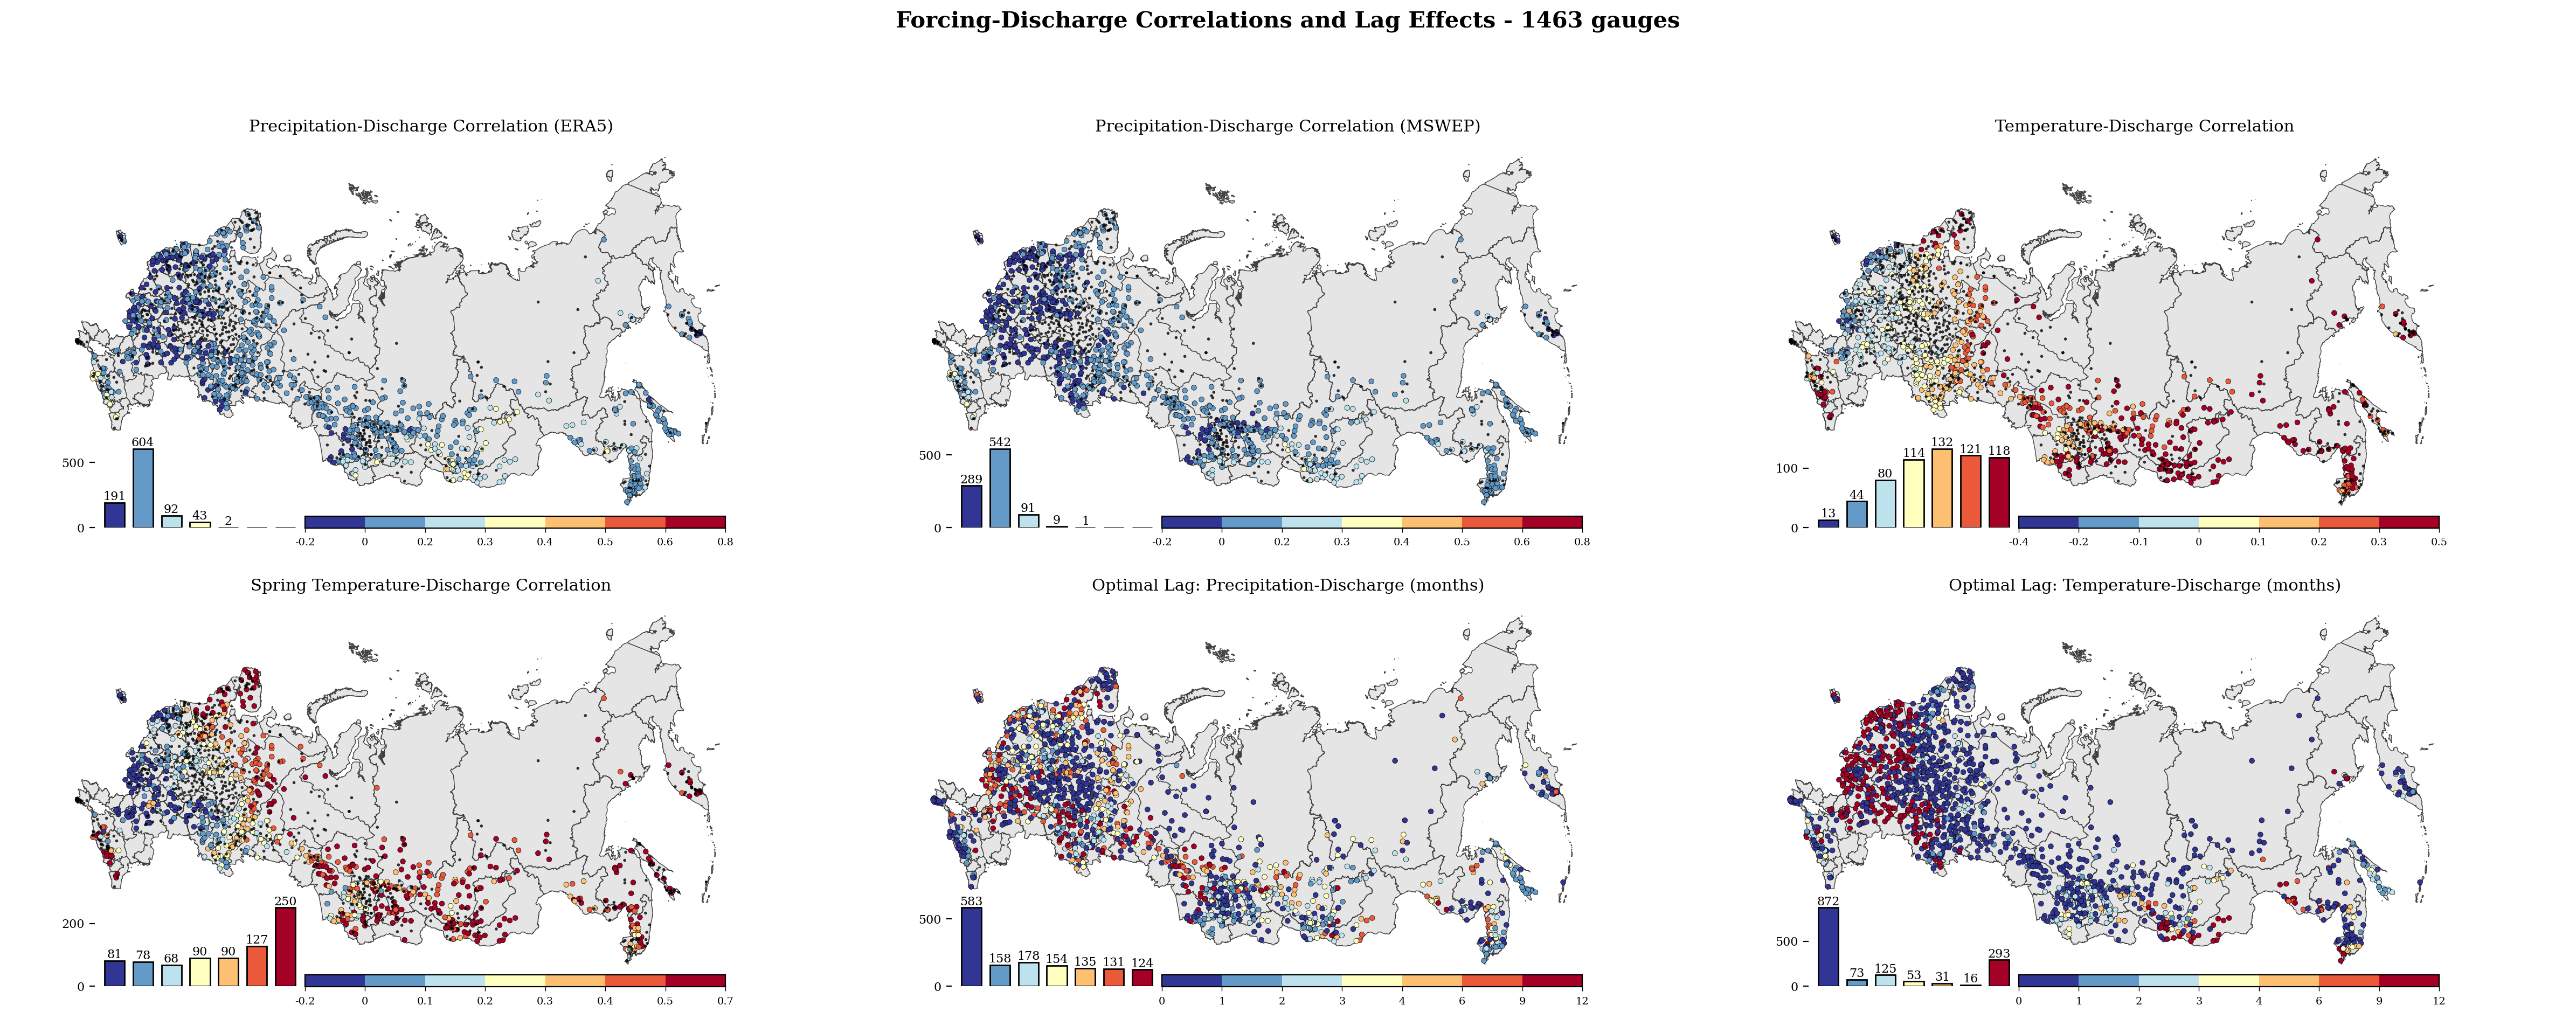

2025-10-13 17:21:10 | INFO     | camels_ru | forcings_final | ℹ️  Correlation spatial maps created


✓ Correlation maps saved


In [28]:
# Correlation spatial maps
corr_metrics_map = [
    "prcp_era5_q_pearson_r",
    "prcp_mswep_q_pearson_r",
    "temp_q_pearson_r",
    "spring_temp_q_pearson_r",
    "prcp_era5_q_best_lag",
    "temp_q_best_lag",
]

corr_titles_map = [
    "Precipitation-Discharge Correlation (ERA5)",
    "Precipitation-Discharge Correlation (MSWEP)",
    "Temperature-Discharge Correlation",
    "Spring Temperature-Discharge Correlation",
    "Optimal Lag: Precipitation-Discharge (months)",
    "Optimal Lag: Temperature-Discharge (months)",
]

corr_bin_intervals = {
    "prcp_era5_q_pearson_r": [
        (-0.2, 0.0),
        (0.0, 0.2),
        (0.2, 0.3),
        (0.3, 0.4),
        (0.4, 0.5),
        (0.5, 0.6),
        (0.6, 0.8),
    ],
    "prcp_mswep_q_pearson_r": [
        (-0.2, 0.0),
        (0.0, 0.2),
        (0.2, 0.3),
        (0.3, 0.4),
        (0.4, 0.5),
        (0.5, 0.6),
        (0.6, 0.8),
    ],
    "temp_q_pearson_r": [
        (-0.4, -0.2),
        (-0.2, -0.1),
        (-0.1, 0.0),
        (0.0, 0.1),
        (0.1, 0.2),
        (0.2, 0.3),
        (0.3, 0.5),
    ],
    "spring_temp_q_pearson_r": [
        (-0.2, 0.0),
        (0.0, 0.1),
        (0.1, 0.2),
        (0.2, 0.3),
        (0.3, 0.4),
        (0.4, 0.5),
        (0.5, 0.7),
    ],
    "prcp_era5_q_best_lag": [(0, 1), (1, 2), (2, 3), (3, 4), (4, 6), (6, 9), (9, 12)],
    "temp_q_best_lag": [(0, 1), (1, 2), (2, 3), (3, 4), (4, 6), (6, 9), (9, 12)],
}

fig_corr_maps = russia_continuous_multiplot(
    gdf_to_plot=combined_df,
    basemap_data=basemap_data,
    metrics=corr_metrics_map,
    titles=corr_titles_map,
    main_title=f"Forcing-Discharge Correlations and Lag Effects - {len(combined_df)} gauges",
    bin_intervals=corr_bin_intervals,
    cmap_name="RdYlBu_r",
    ncols=3,
    subplot_size=(8.0, 5.0),
    with_histogram=True,
    marker_size=12,
)

fig_corr_maps.savefig(
    "../paper/images/forcings_correlations_spatial_maps.png", dpi=300, bbox_inches="tight"
)
display(fig_corr_maps)

logger.info("Correlation spatial maps created")
print("✓ Correlation maps saved")

In [ ]:
import xarray as xr

with xr.open_dataset(
    "/home/dmbrmv/Development/camels_ru/data/MeteoData/ProcessedGauges/Era5Land/res/1569.nc"
) as ds:
    ds = ds.to_dataframe()

ds.loc[:"2007", "prcp"]

date
2007-01-01    0.076836
2007-01-02    0.067688
2007-01-03    0.155488
2007-01-04    0.016295
2007-01-05    0.003244
                ...   
2007-12-27    0.502957
2007-12-28    0.152927
2007-12-29    0.015607
2007-12-30    0.547830
2007-12-31    0.084304
Name: prcp, Length: 365, dtype: float64

In [67]:
gauge_id = "1569"

watershed_area_km2 = ws_gdf.loc[gauge_id, "area"]

(
    pd.read_csv(
        "/home/dmbrmv/Development/camels_ru/data/MeteoData/CamelsRU/era5_land/1569.csv",
        parse_dates=["date"],
        index_col="date",
    )["prcp"]
).groupby(pd.Grouper(freq="YE")).sum() * 1e-3 * watershed_area_km2 * 1e6

date
2007-12-31    1.348027e+07
Freq: YE-DEC, Name: prcp, dtype: float64

In [90]:
import xarray as xr

with xr.open_dataset(
    "/home/dmbrmv/Development/camels_ru/data/MeteoData/ProcessedGauges/Era5Land/res/1569.nc"
) as ds:
    ds = ds.to_dataframe()

ds.loc[:"02-2007", "prcp"].groupby(pd.Grouper(freq="ME")).sum()


date
2007-01-31     5.308995
2007-02-28    23.369891
Freq: ME, Name: prcp, dtype: float64

In [2]:
import pandas as pd

pd.read_csv(
    "/home/dmbrmv/Development/camels_ru/data/MeteoData/CamelsRU/era5_land/1569.csv",
    parse_dates=["date"],
    index_col="date",
).loc[:"02-2007", "prcp"].groupby(pd.Grouper(freq="ME")).sum()


date
2007-01-31    0.034108
2007-02-28    0.149958
Freq: ME, Name: prcp, dtype: float64

### 6.2 Water Balance and Volume Relationship Maps

Visualize runoff coefficients, water deficits, and P-Q volume relationships.

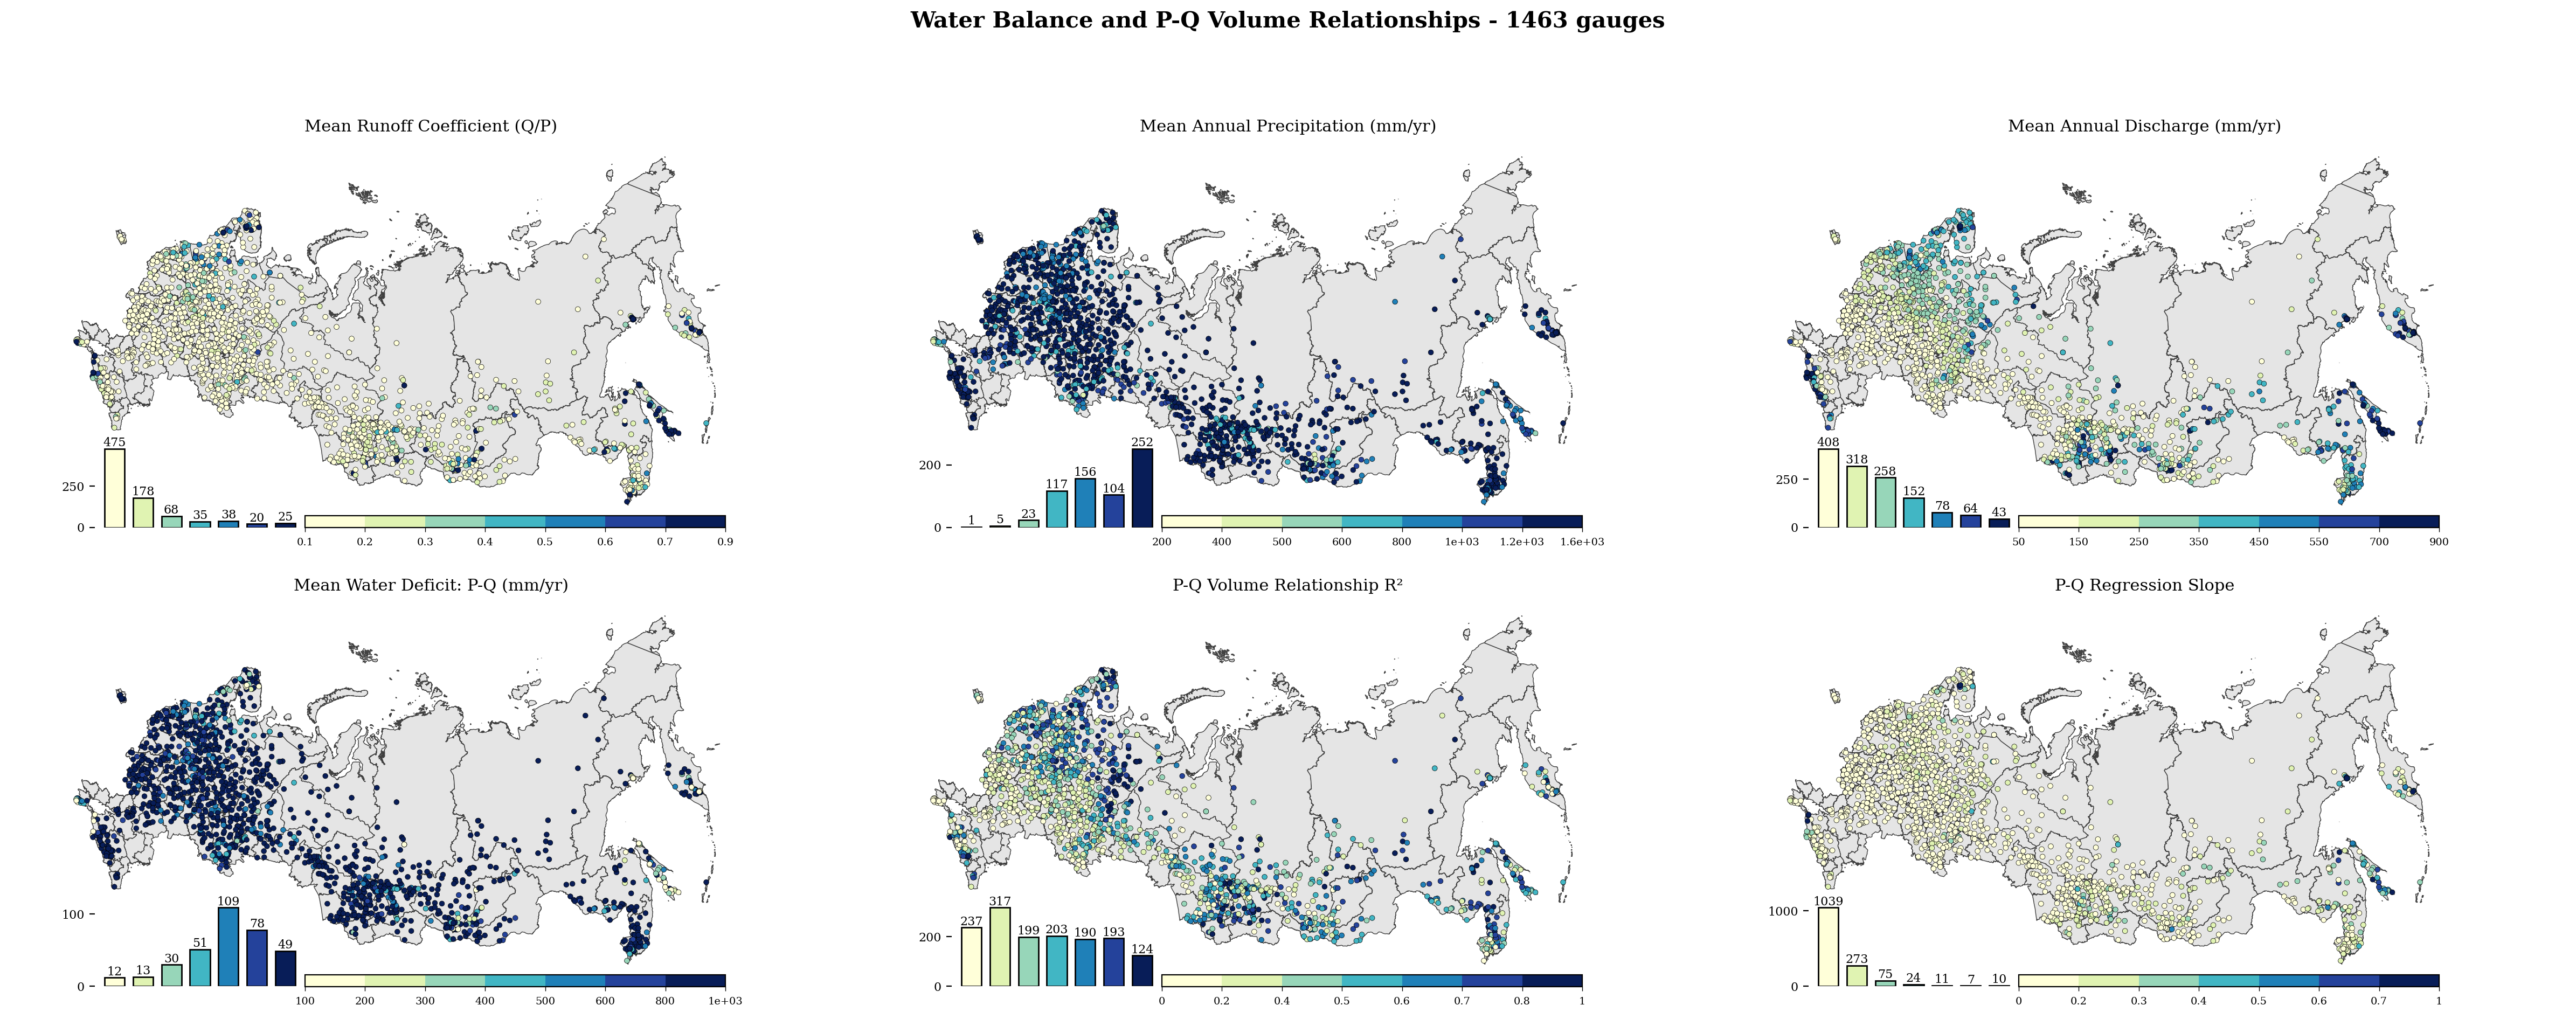

2025-10-13 17:22:09 | INFO     | camels_ru | forcings_final | ℹ️  Water balance spatial maps created


✓ Water balance maps saved


In [30]:
# Water balance spatial maps
wb_metrics_map = [
    "era5_mean_runoff_coefficient",
    "era5_mean_annual_prcp",
    "era5_mean_annual_discharge",
    "era5_mean_water_deficit",
    "era5_prcp_discharge_r_squared",
    "era5_prcp_discharge_slope",
]

wb_titles_map = [
    "Mean Runoff Coefficient (Q/P)",
    "Mean Annual Precipitation (mm/yr)",
    "Mean Annual Discharge (mm/yr)",
    "Mean Water Deficit: P-Q (mm/yr)",
    "P-Q Volume Relationship R²",
    "P-Q Regression Slope",
]

wb_bin_intervals = {
    "era5_mean_runoff_coefficient": [
        (0.1, 0.2),
        (0.2, 0.3),
        (0.3, 0.4),
        (0.4, 0.5),
        (0.5, 0.6),
        (0.6, 0.7),
        (0.7, 0.9),
    ],
    "era5_mean_annual_prcp": [
        (200, 400),
        (400, 500),
        (500, 600),
        (600, 800),
        (800, 1000),
        (1000, 1200),
        (1200, 1600),
    ],
    "era5_mean_annual_discharge": [
        (50, 150),
        (150, 250),
        (250, 350),
        (350, 450),
        (450, 550),
        (550, 700),
        (700, 900),
    ],
    "era5_mean_water_deficit": [
        (100, 200),
        (200, 300),
        (300, 400),
        (400, 500),
        (500, 600),
        (600, 800),
        (800, 1000),
    ],
    "era5_prcp_discharge_r_squared": [
        (0.0, 0.2),
        (0.2, 0.4),
        (0.4, 0.5),
        (0.5, 0.6),
        (0.6, 0.7),
        (0.7, 0.8),
        (0.8, 1.0),
    ],
    "era5_prcp_discharge_slope": [
        (0.0, 0.2),
        (0.2, 0.3),
        (0.3, 0.4),
        (0.4, 0.5),
        (0.5, 0.6),
        (0.6, 0.7),
        (0.7, 1.0),
    ],
}

fig_wb_maps = russia_continuous_multiplot(
    gdf_to_plot=combined_df,
    basemap_data=basemap_data,
    metrics=wb_metrics_map,
    titles=wb_titles_map,
    main_title=f"Water Balance and P-Q Volume Relationships - {len(combined_df)} gauges",
    bin_intervals=wb_bin_intervals,
    cmap_name="YlGnBu",
    ncols=3,
    subplot_size=(8.0, 5.0),
    with_histogram=True,
    marker_size=12,
)

fig_wb_maps.savefig("../paper/images/water_balance_spatial_maps.png", dpi=300, bbox_inches="tight")
display(fig_wb_maps)

logger.info("Water balance spatial maps created")
print("✓ Water balance maps saved")

## 7. Final Summary and Data Export

### 7.1 Save Complete Analysis Dataset

In [31]:
# Export complete analysis dataset
output_geopackage = "../results/forcings_discharge_complete_analysis.gpkg"
output_csv = "../results/forcings_discharge_complete_analysis.csv"

# Save as GeoPackage (with geometry)
combined_df.to_file(output_geopackage, driver="GPKG")
logger.info(f"Saved complete analysis to GeoPackage: {output_geopackage}")

# Save as CSV (without geometry)
combined_df_csv = combined_df.drop(columns=["geometry"])
combined_df_csv.to_csv(output_csv, index_label="gauge_id")
logger.info(f"Saved complete analysis to CSV: {output_csv}")

print("=" * 100)
print("FINAL DATASET EXPORT")
print("=" * 100)
print(f"✓ GeoPackage: {output_geopackage}")
print(f"✓ CSV: {output_csv}")
print("\nDataset summary:")
print(f"  - Total gauges: {len(combined_df)}")
print(f"  - Total attributes: {len(combined_df.columns)}")
print(
    f"  - Hydrological metrics: {len([c for c in combined_df.columns if c.startswith('mean_') or c.startswith('q')])}"
)
print(
    f"  - Meteorological trends: {len([c for c in combined_df.columns if 'sen_slope' in c or 'mk_' in c])}"
)
print(f"  - Correlations: {len([c for c in combined_df.columns if 'pearson' in c or 'spearman' in c])}")
print(
    f"  - Water balance: {len([c for c in combined_df.columns if 'runoff_coefficient' in c or 'water_deficit' in c])}"
)
print("=" * 100)

2025-10-13 17:23:17 | INFO     | camels_ru | forcings_final | ℹ️  Saved complete analysis to GeoPackage: ../results/forcings_discharge_complete_analysis.gpkg
2025-10-13 17:23:17 | INFO     | camels_ru | forcings_final | ℹ️  Saved complete analysis to CSV: ../results/forcings_discharge_complete_analysis.csv
2025-10-13 17:23:17 | INFO     | camels_ru | forcings_final | ℹ️  Saved complete analysis to CSV: ../results/forcings_discharge_complete_analysis.csv


FINAL DATASET EXPORT
✓ GeoPackage: ../results/forcings_discharge_complete_analysis.gpkg
✓ CSV: ../results/forcings_discharge_complete_analysis.csv

Dataset summary:
  - Total gauges: 1463
  - Total attributes: 179
  - Hydrological metrics: 14
  - Meteorological trends: 24
  - Correlations: 16
  - Water balance: 8
